# Signals in the Noise — RCA weekly freight forecasting
**Production notebook.** Weekly training on 10 business-unit groups, forecasts aggregated to month / quarter /
year. Models (endogenous only, no macroeconomic inputs): seasonal-naive, ETS, SARIMA, Prophet (holiday-aware),
XGBoost (+ optional LSTM for mineral oil).

### Requirements
```bash
pip install pandas numpy matplotlib statsmodels prophet xgboost holidays torch
```
### Configuration
Point `SRC` at the master file `MasterPredictions200501-202604.xlsx`.

In [34]:
# import packages for the whole notebook 
import os
import numpy as np
import pandas as pd
import random
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from xgboost import XGBRegressor
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt
import holidays as hol_lib
import matplotlib.ticker as mt
import warnings
warnings.filterwarnings("ignore")

# ---- reproducibility: fix all random seeds ----
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
except ImportError:
    pass

PROJECT  = os.path.expanduser("~/Documents/EMBA/MasterThesis")
SRC      = os.path.join(PROJECT, "Data", "MasterPredictions200501-202604.xlsx")
HOLD_W   = 104          # weeks held out (2 years)
PER      = 52           # weekly annual season

UNIT2GROUP = {
 "Agriculture":"agriculture","Automotive":"automotive","Build.M./Constr.Log.":"buildingmaterials",
 "Chemicals":"chemicals","Consumer Goods":"consumergoods","Environmental":"environmental",
 "Mineral Oil":"mineraloil","Paper":"paper","Wood":"wood",
 "Voest":"montan","Steel":"montan","Energy/Raw Materials":"montan",
}  # excluded: Intermodal (UKV/ROLA), Empty Wagons, residual/overhead/n.def./BU MAC
GROUPS = ["agriculture","automotive","buildingmaterials","chemicals","consumergoods",
          "environmental","mineraloil","montan","paper","wood"]
print("config set")

config set


## 1  Build the weekly panel from the master file
VJA = year of shipment, VKW = ISO week of shipment, Geschäftseinheit = unit, TOKM = tonne-kilometres.
The valuation fields (BWJAMO) and VMO are ignored. Incomplete tail weeks of 2026 (and the spurious week 53)
are dropped.

In [35]:
df = pd.read_excel(SRC, engine="openpyxl", usecols=["VJA","VKW","Geschäftseinheit","TOKM"])
df["group"] = df["Geschäftseinheit"].map(UNIT2GROUP)
df = df.dropna(subset=["group"])
df = df[~((df.VJA == 2026) & (df.VKW > 18))]                 # drop incomplete 2026 tail + stray week 53
df["TTOKM"] = df["TOKM"] / 1000.0                            # -> thousand tonne-km

g = df.groupby(["group","VJA","VKW"], as_index=False)["TTOKM"].sum()
def iso(y, w):
    try: return pd.Timestamp.fromisocalendar(int(y), int(w), 1)
    except: return pd.NaT
g["date"] = [iso(y, w) for y, w in zip(g.VJA, g.VKW)]
W = g.dropna(subset=["date"]).sort_values(["group","date"])

def wser(grp):
    s = (W.groupby("date")["TTOKM"].sum() if grp=="TOTAL"
         else W[W.group==grp].set_index("date")["TTOKM"])
    return s[~s.index.duplicated()].sort_index()

print("weeks per group:", W.groupby("group").size().to_dict())
print("range:", W.date.min().date(), "->", W.date.max().date())

weeks per group: {'agriculture': 1113, 'automotive': 1113, 'buildingmaterials': 1113, 'chemicals': 1113, 'consumergoods': 1113, 'environmental': 1113, 'mineraloil': 1113, 'montan': 1113, 'paper': 1113, 'wood': 1113}
range: 2005-01-03 -> 2026-04-27


## 2  Helpers: calendar feature, Fourier terms, metrics, aggregation
For the long 52-week season we use **deterministic Fourier terms** (date-derived, not macro data) in the SARIMA
estimator — the standard, fast way to model annual seasonality in weekly data (a full seasonal_order with s=52
is impractically slow). `hol_week` provides the public-holiday count used only by Prophet.

In [36]:
def hol_week(idx):
    at = hol_lib.Austria()
    out=[]
    for ts in idx:
        days=[ (ts+pd.Timedelta(days=d)) for d in range(7)]
        out.append(sum(1 for d in days if d in at))
    return np.array(out, float)

def fourier(idx, K=5, period=PER):
    w = idx.isocalendar().week.values.astype(float)
    cols=[]
    for k in range(1,K+1):
        cols += [np.sin(2*np.pi*k*w/period), np.cos(2*np.pi*k*w/period)]
    return np.column_stack(cols)

def mape(a,f): a,f=np.asarray(a,float),np.asarray(f,float); return np.mean(np.abs((a-f)/a))*100
def agg(s,fr): return s.groupby(s.index.to_period(fr)).sum()
def agg_mape(actual_w, fc_w, fr):
    a=agg(actual_w,fr); f=agg(pd.Series(fc_w,index=actual_w.index),fr); ix=a.index.intersection(f.index)
    return mape(a[ix], f[ix])
print("helpers ready")

helpers ready


## 3  Models (weekly)

In [37]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def f_snaive(tr,h,fidx):
    v=list(tr.values); return np.array([v[-PER] if i<PER else v[-PER+(i%PER)] for i in range(h)])

def f_ets(tr,h,fidx):
    return ExponentialSmoothing(tr, trend="add", seasonal="add", seasonal_periods=PER).fit().forecast(h).values

def f_sarima(tr,h,fidx):
    # SARIMA(2,1,1) + deterministic Fourier(K=5) terms for the annual cycle (no macro inputs).
    # statsmodels' SARIMAX class is just the estimator here; the Fourier terms are date-derived, not exogenous data.
    Ftr=fourier(tr.index); Ff=fourier(fidx)
    fit=SARIMAX(tr, exog=Ftr, order=(2,1,1), enforce_stationarity=False,
                enforce_invertibility=False).fit(disp=False)
    return fit.forecast(h, exog=Ff).values

def f_prophet(tr,h,fidx):
    from prophet import Prophet
    d=pd.DataFrame({"ds":tr.index,"y":tr.values})
    mdl=Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                changepoint_prior_scale=0.05)
    mdl.add_country_holidays(country_name="AT")   # deterministic calendar (holidays), not macro
    mdl.fit(d)
    return mdl.predict(pd.DataFrame({"ds":fidx}))["yhat"].values

def f_xgboost(tr,h,fidx):
    from xgboost import XGBRegressor
    y=tr.values.astype(float); idx=tr.index
    def fr(ti,fi,hist):
        return [ti,hist[-1],hist[-2],hist[-4],hist[-PER],np.mean(hist[-4:]),np.mean(hist[-PER:])] + \
               [int(fi.month==k) for k in range(1,13)]
    X=[fr(ti,idx[ti],y[:ti]) for ti in range(PER+4,len(y))]; Y=y[PER+4:]
    mdl=XGBRegressor(n_estimators=300,max_depth=3,learning_rate=0.05,subsample=0.9,
                     random_state=SEED,n_jobs=1).fit(np.array(X),Y)
    hist=list(y); out=[]
    for i in range(h):
        row=np.array(fr(len(y)+i,fidx[i],np.array(hist))).reshape(1,-1)
        p=float(mdl.predict(row)[0]); out.append(p); hist.append(p)
    return np.array(out)

MODELS={"SeasonalNaive":f_snaive,"ETS":f_ets,"SARIMA":f_sarima,
        "Prophet":f_prophet,"XGBoost":f_xgboost}   # endogenous only; SARIMAX (macro) dropped
print("models defined")

models defined


## 4  Back-test: weekly forecast, error at weekly/monthly/quarterly/annual

In [38]:
def backtest(g):
    s=wser(g).dropna(); tr=s.iloc[:-HOLD_W]; te=s.iloc[-HOLD_W:]
    rec={}
    for name,fn in MODELS.items():
        try:
            fc=fn(tr,HOLD_W,te.index)
            rec[name]={"weekly":mape(te.values,fc),
                       "monthly":agg_mape(te,fc,"M"),
                       "quarterly":agg_mape(te,fc,"Q"),
                       "annual":agg_mape(te,fc,"Y")}
        except Exception as e:
            rec[name]={"weekly":np.nan,"monthly":np.nan,"quarterly":np.nan,"annual":np.nan}
            print(g,name,"failed:",e)
    return rec

results={g:backtest(g) for g in ["TOTAL"]+GROUPS}
tbl=pd.DataFrame({g:{m:results[g][m]["monthly"] for m in MODELS} for g in results}).T.round(1)
print("Monthly-aggregated MAPE %:"); display(tbl)
# aggregation benefit for the total
pd.DataFrame(results["TOTAL"]).T.round(2)

18:02:59 - cmdstanpy - INFO - Chain [1] start processing
18:03:00 - cmdstanpy - INFO - Chain [1] done processing
18:03:00 - cmdstanpy - INFO - Chain [1] start processing
18:03:00 - cmdstanpy - INFO - Chain [1] done processing
18:03:00 - cmdstanpy - INFO - Chain [1] start processing
18:03:00 - cmdstanpy - INFO - Chain [1] done processing
18:03:01 - cmdstanpy - INFO - Chain [1] start processing
18:03:01 - cmdstanpy - INFO - Chain [1] done processing
18:03:01 - cmdstanpy - INFO - Chain [1] start processing
18:03:01 - cmdstanpy - INFO - Chain [1] done processing
18:03:02 - cmdstanpy - INFO - Chain [1] start processing
18:03:02 - cmdstanpy - INFO - Chain [1] done processing
18:03:02 - cmdstanpy - INFO - Chain [1] start processing
18:03:02 - cmdstanpy - INFO - Chain [1] done processing
18:03:03 - cmdstanpy - INFO - Chain [1] start processing
18:03:03 - cmdstanpy - INFO - Chain [1] done processing
18:03:03 - cmdstanpy - INFO - Chain [1] start processing
18:03:03 - cmdstanpy - INFO - Chain [1]

Monthly-aggregated MAPE %:


,SeasonalNaive,ETS,SARIMA,Prophet,XGBoost
TOTAL,5.8,4.4,4.9,6.3,5.0
agriculture,32.6,29.1,19.5,22.6,18.9
automotive,48.1,15.4,21.1,12.9,35.0
buildingmaterials,12.3,11.1,6.3,13.4,7.5
chemicals,11.4,10.7,9.1,16.9,12.0
consumergoods,92.5,62.6,53.6,62.1,52.4
environmental,12.9,6.8,8.8,7.4,7.8
mineraloil,21.5,9.2,7.7,7.9,7.6
montan,10.2,5.8,8.4,7.8,6.9
paper,8.7,10.8,8.8,30.5,5.8


,weekly,monthly,quarterly,annual
SeasonalNaive,10.59,5.76,4.46,3.99
ETS,8.53,4.39,3.87,3.13
SARIMA,9.53,4.89,4.18,3.56
Prophet,8.92,6.32,5.75,5.33
XGBoost,8.94,5.05,3.16,2.00


## 5  Experiment — training-history length (weekly)

In [39]:
for g in ["TOTAL","montan","mineraloil","wood"]:
    s=wser(g).dropna(); te=s.iloc[-HOLD_W:]; hist=s.iloc[:-HOLD_W]; row={}
    for yrs in [5,10,15,20]:
        tr=hist.iloc[-yrs*52:]
        row[yrs]=round(agg_mape(te, f_sarima(tr,HOLD_W,te.index), "M"),2)
    print(g, row)

TOTAL {5: np.float64(5.84), 10: np.float64(5.15), 15: np.float64(5.07), 20: np.float64(4.89)}
montan {5: np.float64(8.09), 10: np.float64(8.22), 15: np.float64(8.09), 20: np.float64(8.37)}
mineraloil {5: np.float64(8.22), 10: np.float64(8.07), 15: np.float64(7.93), 20: np.float64(7.7)}
wood {5: np.float64(10.1), 10: np.float64(9.97), 15: np.float64(9.05), 20: np.float64(8.26)}


## 6  LSTM spotlight — mineral oil (optional, needs torch)

In [40]:
def f_lstm(tr,h,fidx,lookback=52,epochs=200):
    import torch, torch.nn as nn
    torch.manual_seed(SEED); np.random.seed(SEED)   # reproducible weight init
    y=tr.values.astype("float32"); mu,sd=y.mean(),y.std(); z=(y-mu)/sd
    X=np.array([z[i:i+lookback] for i in range(len(z)-lookback)])
    Y=np.array([z[i+lookback] for i in range(len(z)-lookback)])
    Xt=torch.tensor(X).unsqueeze(-1); Yt=torch.tensor(Y).unsqueeze(-1)
    class Net(nn.Module):
        def __init__(s): super().__init__(); s.l=nn.LSTM(1,48,batch_first=True); s.f=nn.Linear(48,1)
        def forward(s,x): o,_=s.l(x); return s.f(o[:,-1])
    net=Net(); opt=torch.optim.Adam(net.parameters(),0.01); L=nn.MSELoss()
    for _ in range(epochs): opt.zero_grad(); L(net(Xt),Yt).backward(); opt.step()
    seq=list(z[-lookback:]); out=[]
    for _ in range(h):
        xi=torch.tensor(np.array(seq[-lookback:],dtype="float32")).reshape(1,lookback,1)
        p=float(net(xi).item()); out.append(p); seq.append(p)
    return np.array(out)*sd+mu

s=wser("mineraloil").dropna(); tr=s.iloc[:-HOLD_W]; te=s.iloc[-HOLD_W:]
try:
    fc=f_lstm(tr,HOLD_W,te.index)
    print("mineral oil LSTM — monthly MAPE: %.2f%%" % agg_mape(te,fc,"M"))
except ImportError:
    print("Install torch to run the LSTM cell.")

mineral oil LSTM — monthly MAPE: 7.77%


## 7  Export results

In [41]:
RESULTS_DIR=os.path.join(PROJECT,"results_final"); os.makedirs(RESULTS_DIR,exist_ok=True)
out=pd.DataFrame({g:{m:results[g][m]["monthly"] for m in MODELS} for g in results}).T.round(2)
out.to_csv(os.path.join(RESULTS_DIR,"weekly_model_metrics_monthly.csv"))
# champion model per group (monthly back-test)
champ=pd.DataFrame([(g,min(MODELS,key=lambda k:results[g][k]["monthly"]),
                     round(min(results[g][k]["monthly"] for k in MODELS),2)) for g in results],
                   columns=["group","champion_model","monthly_MAPE"])
champ.to_csv(os.path.join(RESULTS_DIR,"champion_per_group.csv"),index=False)
print("written to", RESULTS_DIR); champ

written to /Users/Hans/Documents/EMBA/MasterThesis/results_final


,group,champion_model,monthly_MAPE
0,TOTAL,ETS,4.39
1,agriculture,XGBoost,18.92
2,automotive,Prophet,12.89
3,buildingmaterials,SARIMA,6.35
4,chemicals,SARIMA,9.10
5,consumergoods,XGBoost,52.44
6,environmental,ETS,6.84
7,mineraloil,XGBoost,7.59
8,montan,ETS,5.75
9,paper,XGBoost,5.82


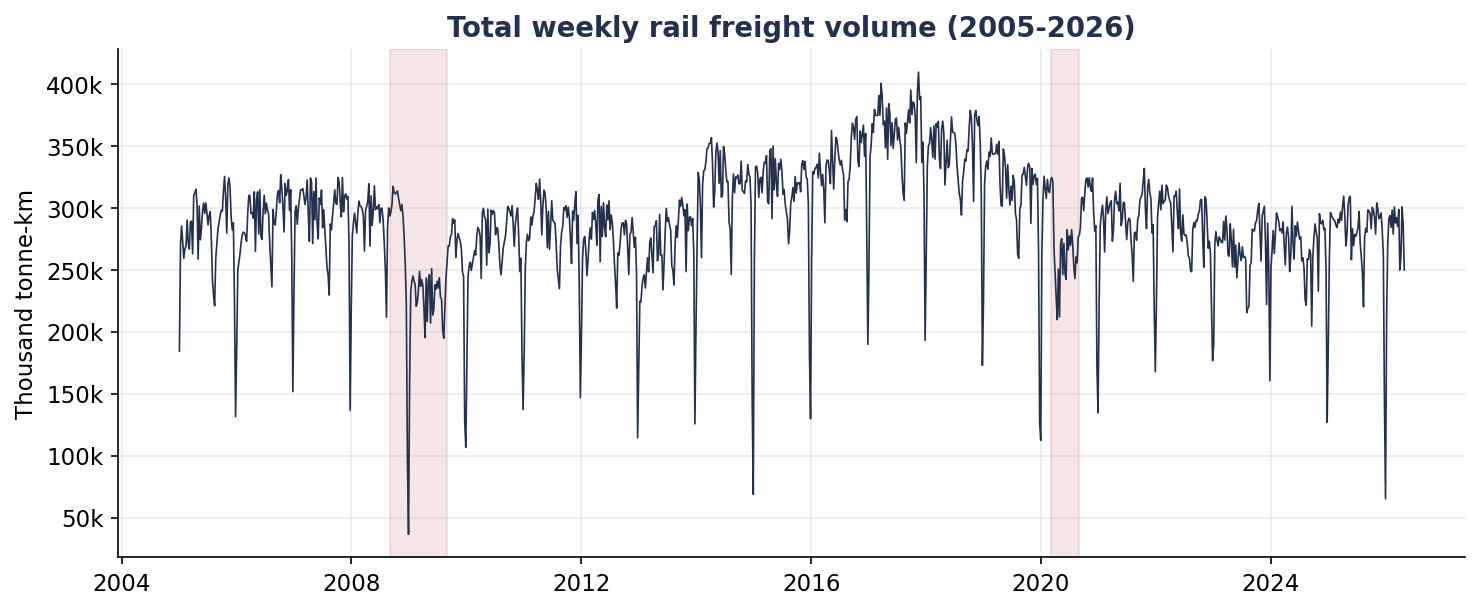

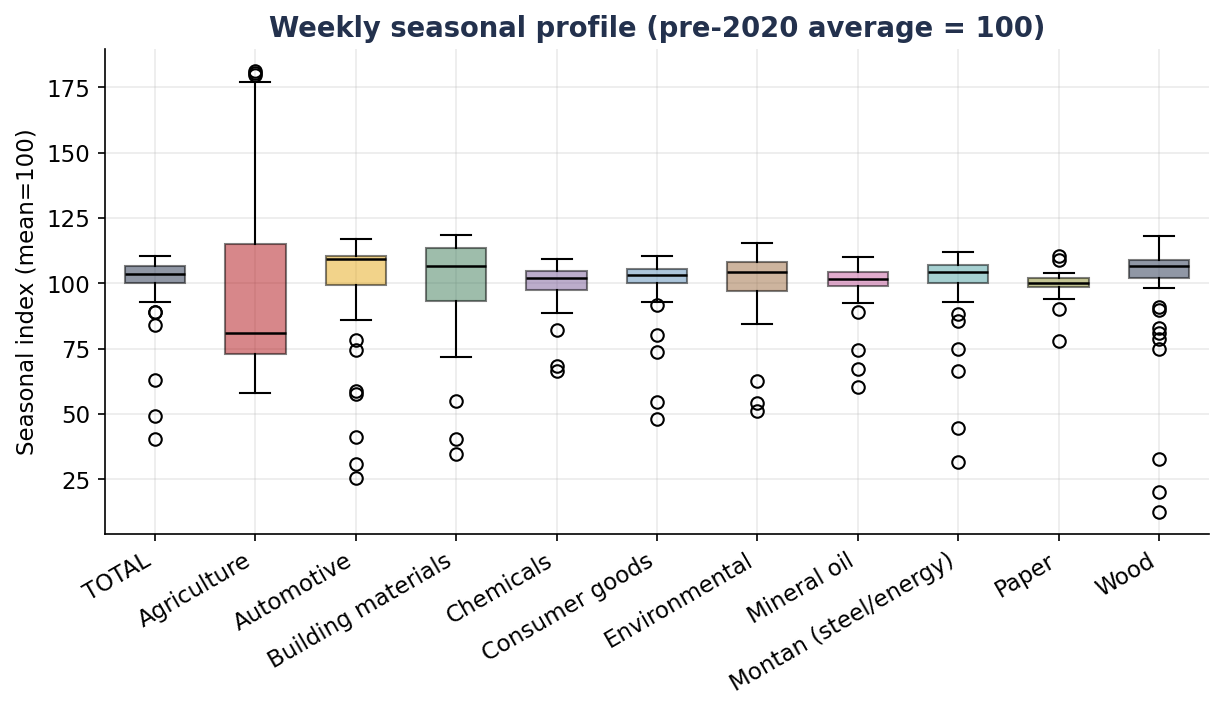

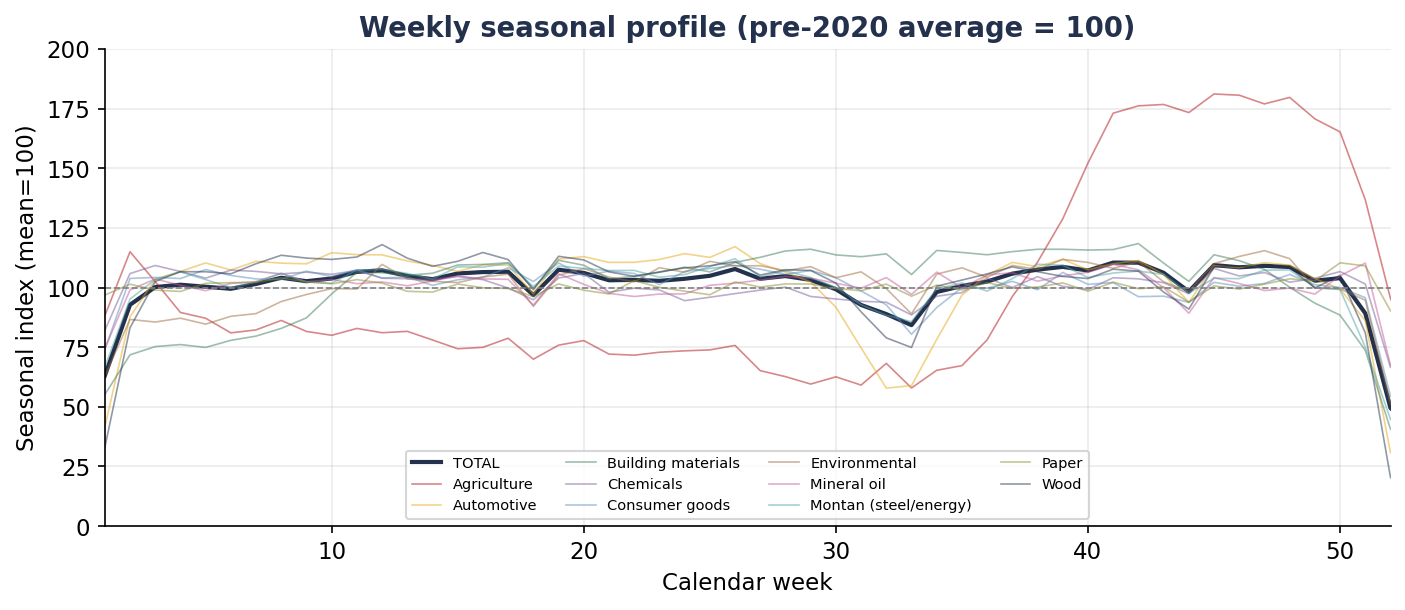

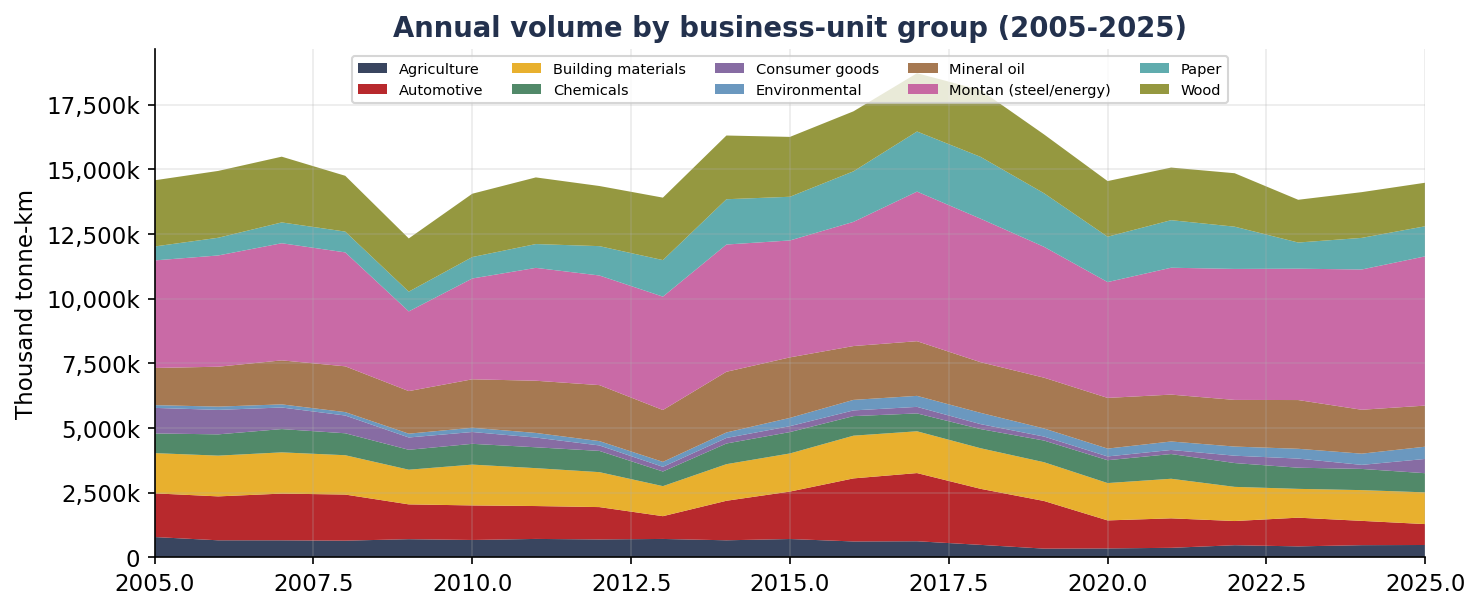

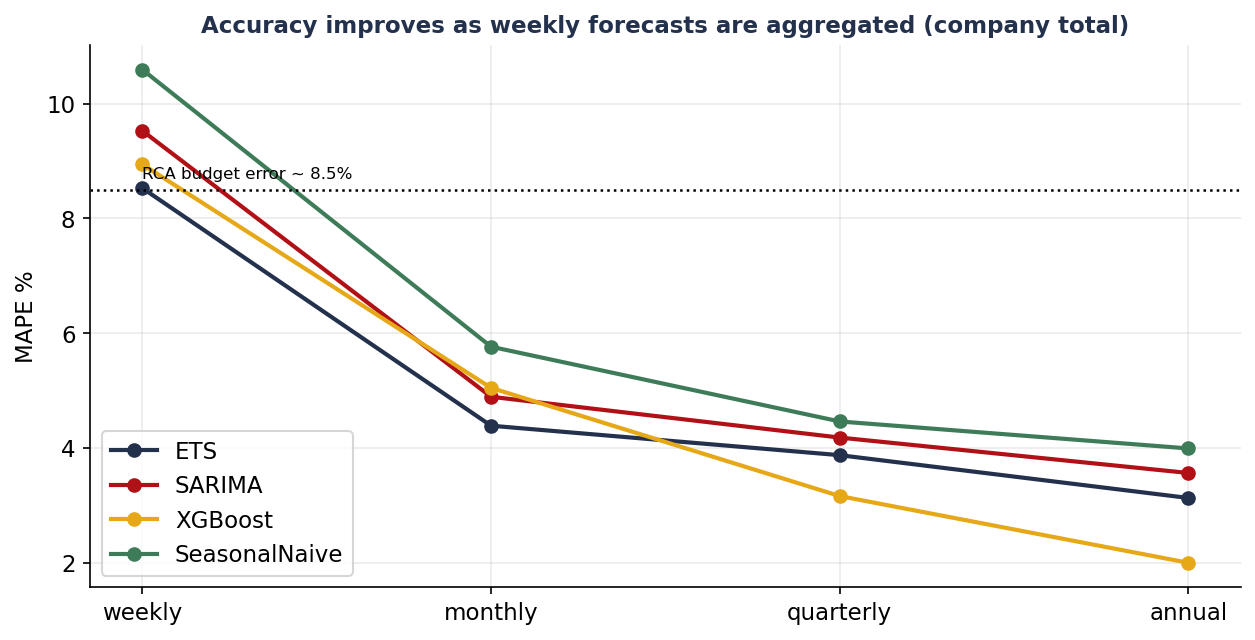

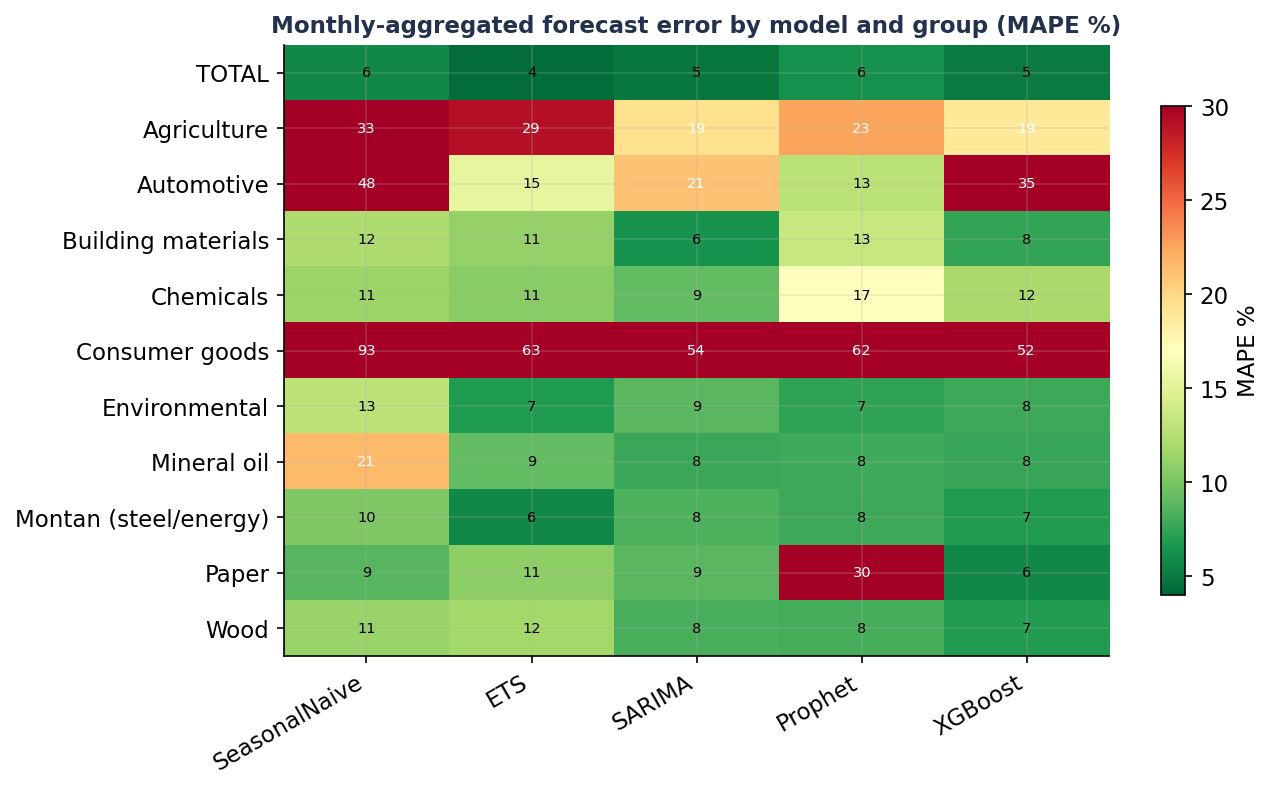

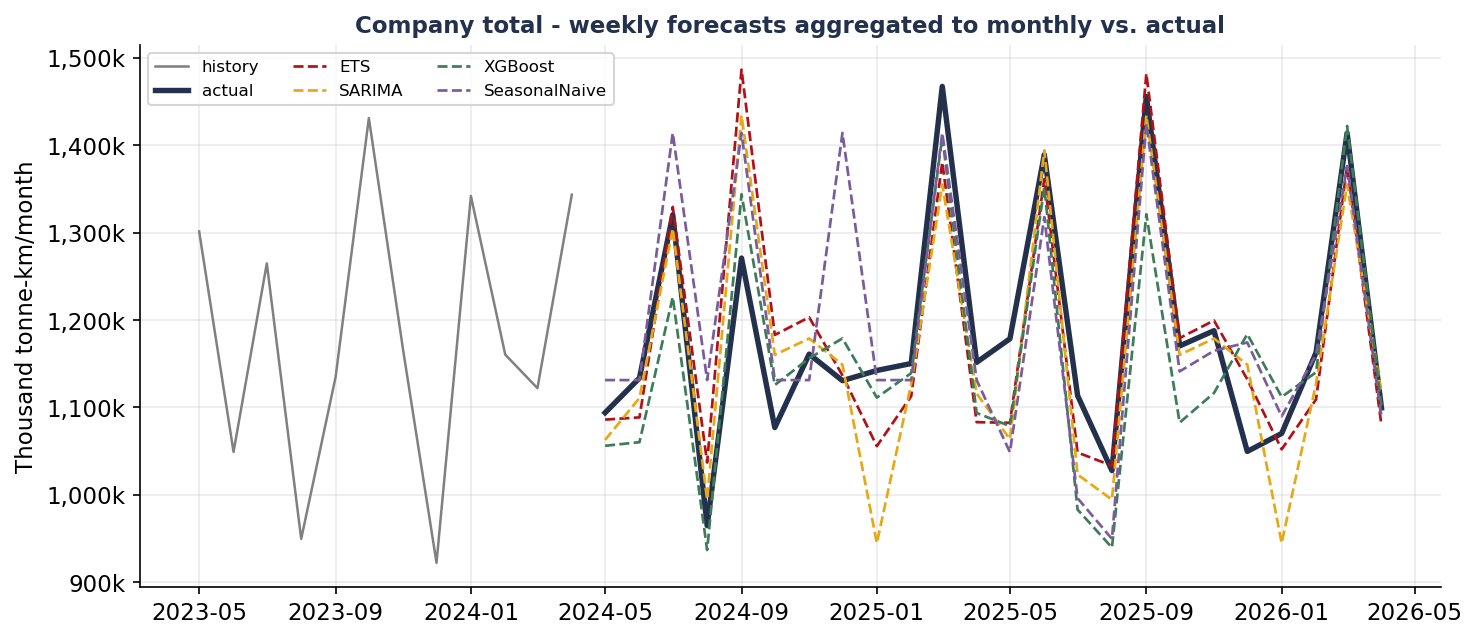

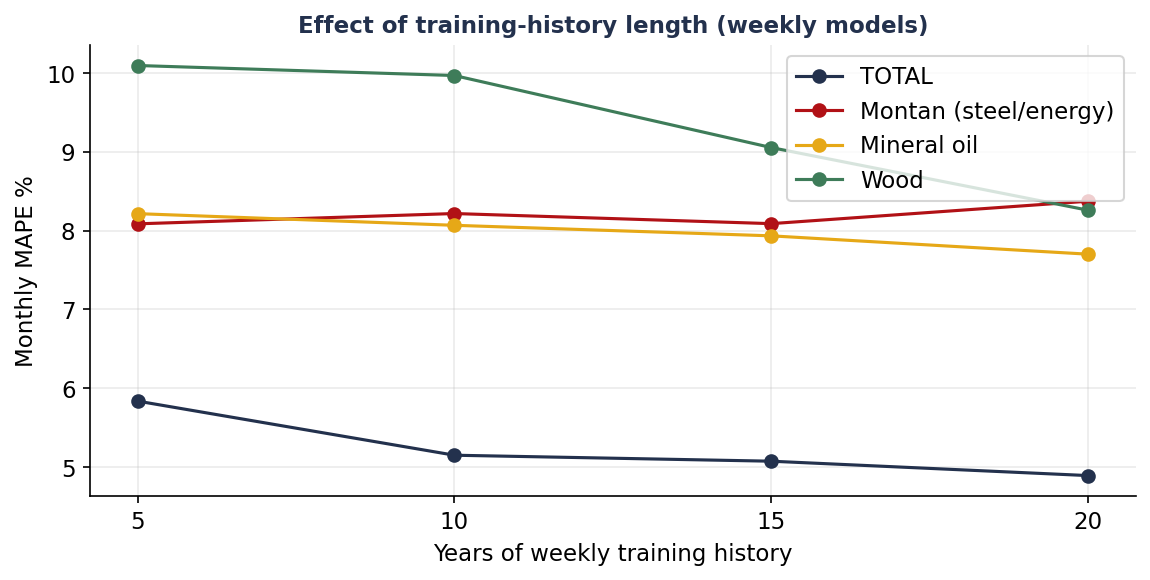

All thesis figures saved to /Users/Hans/Documents/EMBA/MasterThesis/results_final/figures


In [ ]:
# ---- thesis figures, generated from the notebook's results ----

FIGDIR = os.path.join(PROJECT, "results_final", "figures"); os.makedirs(FIGDIR, exist_ok=True)
plt.rcParams.update({"figure.dpi":150,"font.size":11,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":.25})
NAVY="#23314D"; RED="#B11116"
PAL=["#23314D","#B11116","#E6A817","#3E7C59","#7A5C99","#5B8DB8","#9C6B3F","#C45A9C","#4FA3A5","#8A8D2B"]
PRETTY={"agriculture":"Agriculture","automotive":"Automotive","buildingmaterials":"Building materials",
"chemicals":"Chemicals","consumergoods":"Consumer goods","environmental":"Environmental",
"mineraloil":"Mineral oil","montan":"Montan (steel/energy)","paper":"Paper","wood":"Wood","TOTAL":"TOTAL"}
def kfmt(x,_): return f"{x/1e3:,.0f}k" if abs(x)>=1e3 else f"{x:,.0f}"
def save(fig,name): fig.tight_layout(); fig.savefig(os.path.join(FIGDIR,name)); plt.show()

# Fig 2 — total weekly volume as line chart with recession shading  
s=wser("TOTAL").dropna()
fig,ax=plt.subplots(figsize=(10,4.2)); ax.plot(s.index,s.values,color=NAVY,lw=.8)
ax.axvspan(pd.Timestamp("2008-09-01"),pd.Timestamp("2009-09-01"),color=RED,alpha=.10)
ax.axvspan(pd.Timestamp("2020-03-01"),pd.Timestamp("2020-09-01"),color=RED,alpha=.10)
ax.set_title("Total weekly rail freight volume (2005-2026)",color=NAVY,weight="bold")
ax.set_ylabel("Thousand tonne-km"); ax.yaxis.set_major_formatter(mt.FuncFormatter(kfmt))
save(fig,"fig_total_trend.png")

# Fig 3 - Boxplot of weekly seasonal profile for TOTAL
fig, ax = plt.subplots(figsize=(9.5, 4.2))

ss = wser("TOTAL").dropna()
ss = ss[ss.index.year < 2020]

by_year_week = ss.groupby([ss.index.year, ss.index.isocalendar().week]).mean()
by_year_week = by_year_week.groupby(level=0).transform(lambda x: x / x.mean() * 100)

box_data, week_labels = [], []
for week in range(1, 53):
    vals = [v for (_, w), v in by_year_week.items() if w == week]
    if vals:
        box_data.append(vals)
        week_labels.append(week)

ax.boxplot(box_data, positions=range(1, len(box_data) + 1), widths=0.5,
           patch_artist=True,
           boxprops=dict(facecolor=PAL[0], alpha=0.5),
           medianprops=dict(color="black", lw=1.2))

ax.set_xticks(range(1, len(box_data) + 1))
ax.set_xticklabels(week_labels, rotation=30, ha="right")
ax.set_xlabel("Calendar week")
ax.set_ylabel("Seasonal index (mean=100)")
ax.set_ylim(0, 200)
ax.set_title("Weekly seasonal profile (pre-2020 average = 100)", color=NAVY, weight="bold")

# Fig 4 — weekly seasonal profile
fig,ax=plt.subplots(figsize=(9.5,4.2))
for i,g in enumerate(["TOTAL"]+GROUPS):
    ss=wser(g).dropna(); ss=ss[ss.index.year<2020]
    woy=ss.groupby(ss.index.isocalendar().week).mean(); woy=woy/woy.mean()*100
    ax.plot(woy.index,woy.values,color=PAL[i%10],lw=2 if g=="TOTAL" else .8,
            alpha=1 if g=="TOTAL" else .5,label=PRETTY[g])
ax.axhline(100,color="grey",ls="--",lw=.8); ax.set_xlim(1,52); ax.set_ylim(0,200)
ax.set_xlabel("Calendar week"); ax.set_ylabel("Seasonal index (mean=100)")
ax.set_title("Weekly seasonal profile (pre-2020 average = 100)",color=NAVY,weight="bold")
ax.legend(fontsize=7,ncol=4,loc="lower center"); save(fig,"fig_seasonality.png")

# Fig 5 — annual composition by group
ann=W.copy(); ann["year"]=ann["date"].dt.year
A=ann.groupby(["year","group"])["TTOKM"].sum().unstack("group").loc[2005:2025]
fig,ax=plt.subplots(figsize=(10,4.2))
ax.stackplot(A.index,[A[g].values for g in GROUPS],labels=[PRETTY[g] for g in GROUPS],colors=PAL,alpha=.9)
ax.set_title("Annual volume by business-unit group (2005-2025)",color=NAVY,weight="bold")
ax.set_ylabel("Thousand tonne-km"); ax.yaxis.set_major_formatter(mt.FuncFormatter(kfmt))
ax.legend(fontsize=7, ncol=5, loc="upper center")
ax.set_xlim(2005, 2025)
save(fig, "fig_composition.png")

# Fig 6 — aggregation benefit (company total)
levels=["weekly","monthly","quarterly","annual"]
fig,ax=plt.subplots(figsize=(8.5,4.4))
for i,mdl in enumerate(["ETS","SARIMA","XGBoost","SeasonalNaive"]):
    ax.plot(levels,[results["TOTAL"][mdl][l] for l in levels],marker="o",color=PAL[i],label=mdl,lw=2)
ax.axhline(8.5,color="black",ls=":",lw=1.2); ax.text(0,8.7,"RCA budget error ~ 8.5%",fontsize=8)
ax.set_ylabel("MAPE %"); ax.set_title("Accuracy improves as weekly forecasts are aggregated (company total)",
            color=NAVY,weight="bold",fontsize=11)
ax.legend(); save(fig,"fig_agg_benefit.png")

# Fig 7 — model x group error heatmap
rows=["TOTAL"]+GROUPS; cols=list(MODELS)
Z=np.array([[results[g][m]["monthly"] for m in cols] for g in rows])
fig,ax=plt.subplots(figsize=(9,5.4))
im=ax.imshow(np.clip(Z,0,30),cmap="RdYlGn_r",aspect="auto",vmin=4,vmax=30)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols,rotation=30,ha="right")
ax.set_yticks(range(len(rows))); ax.set_yticklabels([PRETTY[g] for g in rows])
for i in range(len(rows)):
    for j in range(len(cols)):
        ax.text(j,i,f"{Z[i,j]:.0f}",ha="center",va="center",fontsize=7,
                color="white" if Z[i,j]>18 else "black")
ax.set_title("Monthly-aggregated forecast error by model and group (MAPE %)",color=NAVY,weight="bold",fontsize=11)
fig.colorbar(im,label="MAPE %",shrink=.8); save(fig,"fig_heatmap.png")

# Fig 8 — forecast vs actual (company total, weekly -> monthly)
s=wser("TOTAL").dropna(); tr=s.iloc[:-HOLD_W]; te=s.iloc[-HOLD_W:]
plot_models=["ETS","SARIMA","XGBoost","SeasonalNaive"]
fcw={name:pd.Series(MODELS[name](tr,HOLD_W,te.index),index=te.index) for name in plot_models}
am=te.groupby(te.index.to_period("M")).sum(); idx=am.index.to_timestamp()
histm=s.groupby(s.index.to_period("M")).sum().iloc[-36:-24]
fig,ax=plt.subplots(figsize=(10,4.4))
ax.plot(histm.index.to_timestamp(),histm.values,color="grey",lw=1.2,label="history")
ax.plot(idx,am.values,color=NAVY,lw=2.6,label="actual")
for i,mdl in enumerate(plot_models):
    fm=fcw[mdl].groupby(fcw[mdl].index.to_period("M")).sum().reindex(am.index)
    ax.plot(idx,fm.values,lw=1.3,ls="--",color=PAL[(i+1)%10],label=mdl)
ax.set_title("Company total - weekly forecasts aggregated to monthly vs. actual",color=NAVY,weight="bold",fontsize=11)
ax.set_ylabel("Thousand tonne-km/month"); ax.yaxis.set_major_formatter(mt.FuncFormatter(kfmt))
ax.legend(fontsize=8,ncol=3); save(fig,"fig_total_forecast.png")

# Fig 9 — training-history length
def hist_mape(g,yrs):
    s=wser(g).dropna(); te=s.iloc[-HOLD_W:]; h=s.iloc[:-HOLD_W]; tr=h.iloc[-yrs*PER:]
    return agg_mape(te, f_sarima(tr,HOLD_W,te.index), "M")
yrs=[5,10,15,20]
fig,ax=plt.subplots(figsize=(7.8,4))
for i,g in enumerate(["TOTAL","montan","mineraloil","wood"]):
    ax.plot(yrs,[hist_mape(g,y) for y in yrs],marker="o",color=PAL[i],label=PRETTY[g])
ax.set_xticks(yrs); ax.set_xlabel("Years of weekly training history"); ax.set_ylabel("Monthly MAPE %")
ax.set_title("Effect of training-history length (weekly models)",color=NAVY,weight="bold",fontsize=11)
ax.legend(); save(fig,"fig_history.png")

print("All thesis figures saved to", FIGDIR)

## 9  Tables for the thesis (match the Word document)
Run after the back-test section (needs `results`, `W`, `wser`, `f_sarima`, `agg_mape`, `MODELS`).
Builds every table in the thesis from the notebook's own results, shows them, and writes them to
`results_final/thesis_tables.xlsx` (one sheet per table) so they can be pasted into the document.

| Sheet | Word table |
|-------|-----------|
| Table1_groups | Table 1 — Groups & 2024 share |
| Table2_aggregation | Table 2 — Company-total error by aggregation |
| Table3_monthly_MAPE | Table 3 — Monthly MAPE by model & group |
| Table4_champion | Table 4 — Champion model per group |
| Table5_history | Table 5 — Error by training-history length |
| AppA_weekly/monthly/quarterly/annual | Appendix A — full MAPE at each level |

In [43]:
# ---- thesis tables, generated from the notebook's own results ----
import os, pandas as pd
try:
    from IPython.display import display
except ImportError:
    display = print

PRETTY={"agriculture":"Agriculture","automotive":"Automotive","buildingmaterials":"Building materials",
"chemicals":"Chemicals","consumergoods":"Consumer goods","environmental":"Environmental",
"mineraloil":"Mineral oil","montan":"Montan (steel/energy)","paper":"Paper","wood":"Wood","TOTAL":"TOTAL"}
ROWS=["TOTAL"]+GROUPS; MODS=list(MODELS)

# Table 1 — groups and share of 2024 volume
y24=W[W["date"].dt.year==2024].groupby("group")["TTOKM"].sum()
share=(y24/y24.sum()*100).round(1).sort_values(ascending=False)
T1=pd.DataFrame({"Commodity group":[PRETTY[g] for g in share.index],
                 "Share of 2024 volume (%)":share.values})

# Table 2 — company-total error by aggregation level
LEVELS=["weekly","monthly","quarterly","annual"]
T2=pd.DataFrame([[m]+[round(results["TOTAL"][m][l],1) for l in LEVELS] for m in MODS],
                columns=["Model","Weekly","Monthly","Quarterly","Annual"])

# Table 3 — monthly-aggregated MAPE by model and group
T3=pd.DataFrame([[PRETTY[g]]+[round(results[g][m]["monthly"],1) for m in MODS] for g in ROWS],
                columns=["Group"]+MODS)

# Table 4 — champion model per group (monthly back-test)
T4=pd.DataFrame([[PRETTY[g], min(MODS,key=lambda k:results[g][k]["monthly"]),
                  round(min(results[g][k]["monthly"] for k in MODS),1)] for g in ROWS],
                columns=["Group","Champion model","Monthly MAPE %"])

# Table 5 — monthly error by length of weekly training history
def _hist(g,yrs):
    s=wser(g).dropna(); te=s.iloc[-HOLD_W:]; h=s.iloc[:-HOLD_W]; tr=h.iloc[-yrs*PER:]
    return round(agg_mape(te, f_sarima(tr,HOLD_W,te.index), "M"),2)
HG=["TOTAL","montan","mineraloil","wood"]; YRS=[5,10,15,20]
T5=pd.DataFrame([[PRETTY[g]]+[_hist(g,y) for y in YRS] for g in HG],
                columns=["Group","5 years","10 years","15 years","20 years"])

# Appendix A — full MAPE at every aggregation level
def _full(level):
    return pd.DataFrame([[PRETTY[g]]+[round(results[g][m][level],1) for m in MODS] for g in ROWS],
                        columns=["Group"]+MODS)
APP={lvl:_full(lvl) for lvl in LEVELS}

for name,t in [("Table 1 — groups & 2024 share",T1),("Table 2 — error by aggregation",T2),
               ("Table 3 — monthly MAPE by model & group",T3),("Table 4 — champion per group",T4),
               ("Table 5 — training-history length",T5)]:
    print("\n"+name); display(t)

# export all to one Excel workbook
xlsx=os.path.join(PROJECT,"results_final","thesis_tables.xlsx")
with pd.ExcelWriter(xlsx) as xl:
    T1.to_excel(xl,sheet_name="Table1_groups",index=False)
    T2.to_excel(xl,sheet_name="Table2_aggregation",index=False)
    T3.to_excel(xl,sheet_name="Table3_monthly_MAPE",index=False)
    T4.to_excel(xl,sheet_name="Table4_champion",index=False)
    T5.to_excel(xl,sheet_name="Table5_history",index=False)
    for lvl in LEVELS: APP[lvl].to_excel(xl,sheet_name=f"AppA_{lvl}",index=False)
print("\nAll thesis tables written to", xlsx)


Table 1 — groups & 2024 share


,Commodity group,Share of 2024 volume (%)
0,Montan (steel/energy),38.4
1,Wood,12.5
2,Mineral oil,12.0
3,Paper,8.7
4,Building materials,8.4
5,Automotive,6.7
6,Chemicals,5.8
7,Agriculture,3.4
8,Environmental,3.1
9,Consumer goods,1.1



Table 2 — error by aggregation


,Model,Weekly,Monthly,Quarterly,Annual
0,SeasonalNaive,10.6,5.8,4.5,4.0
1,ETS,8.5,4.4,3.9,3.1
2,SARIMA,9.5,4.9,4.2,3.6
3,Prophet,8.9,6.3,5.8,5.3
4,XGBoost,8.9,5.0,3.2,2.0



Table 3 — monthly MAPE by model & group


...


Table 4 — champion per group


,Group,Champion model,Monthly MAPE %
0,TOTAL,ETS,4.4
1,Agriculture,XGBoost,18.9
2,Automotive,Prophet,12.9
3,Building materials,SARIMA,6.3
4,Chemicals,SARIMA,9.1
5,Consumer goods,XGBoost,52.4
6,Environmental,ETS,6.8
7,Mineral oil,XGBoost,7.6
8,Montan (steel/energy),ETS,5.8
9,Paper,XGBoost,5.8



Table 5 — training-history length


,Group,5 years,10 years,15 years,20 years
0,TOTAL,5.84,5.15,5.07,4.89
1,Montan (steel/energy),8.09,8.22,8.09,8.37
2,Mineral oil,8.22,8.07,7.93,7.70
3,Wood,10.10,9.97,9.05,8.26



All thesis tables written to /Users/Hans/Documents/EMBA/MasterThesis/results_final/thesis_tables.xlsx
